# НИР: Прогноз вероятности роста цены акций (Мосбиржа)

**Цель:** по дневным свечам с ISS оценить вероятность того, что в течение **21 торгового дня** цена **закрытия** хотя бы раз станет **строго выше** текущего закрытия.

| № | Блок | Что делает |
|---|------|------------|
| 1 | Проверка ISS | Пробная выгрузка свечей по одному тикеру |
| 2 | Функции | Параметры, загрузка свечей, признаки, сплит train/test |
| 3 | Датасет | Загрузка 10 акций + IMOEX, сбор таблицы `ds` |
| 4 | Baseline | Логистическая регрессия + калибровка, метрики |
| 5 | Сравнение | LogReg vs HistGB, график калибровки, прогнозы |
| 6 | Риск | Модель вероятности сильной просадки за горизонт |
| 7 | Рост, % | Регрессия: макс. закрытие за 21 день выше текущей на X% |
| 8 | Итог | Сводная таблица: вероятности, риск, рост % |

Запускайте ячейки **сверху вниз**. Нужен интернет к `iss.moex.com`.


## 1. Проверка доступа к ISS

**Действия:**
- Запрос к `candles.json` для одного тикера (`SECID`, по умолчанию SBER).
- Период: последние 30 календарных дней, `interval=24` (дневные свечи).
- Пагинация через параметр `start` до пустого ответа.
- Расчёт среднего **close** и вывод последних 10 строк таблицы.

**Зачем:** убедиться, что API Мосбиржи доступен и формат данных корректен перед загрузкой панели.


In [32]:
import datetime as dt
import requests
import pandas as pd

# --- настройки ---
SECID = "SBER"  # поменяйте на нужный тикер, например: GAZP, LKOH, YNDX, TCSG

# Последние ~30 дней (календарные). Если нужны строго торговые дни — это тоже можно сделать.
till = dt.date.today()
from_ = till - dt.timedelta(days=30)

url = f"https://iss.moex.com/iss/engines/stock/markets/shares/securities/{SECID}/candles.json"
params = {
    "from": from_.isoformat(),
    "till": till.isoformat(),
    "interval": 24,   # 24 = дневные свечи
    "iss.meta": "off",
    "iss.only": "candles",
}

rows = []
start = 0
while True:
    r = requests.get(url, params={**params, "start": start}, timeout=30)
    r.raise_for_status()
    payload = r.json()["candles"]
    cols = payload["columns"]
    data = payload["data"]

    if not data:
        break

    rows.extend(data)
    start += len(data)

candles = pd.DataFrame(rows, columns=cols)
if candles.empty:
    raise RuntimeError(f"Нет данных по {SECID} за период {from_}..{till}. Проверьте SECID/рынок.")

# Средняя цена за месяц: среднее арифметическое дневных цен закрытия
candles["begin"] = pd.to_datetime(candles["begin"])
avg_close = float(pd.to_numeric(candles["close"], errors="coerce").dropna().mean())

print(f"{SECID}: средняя цена закрытия за последние 30 дней ({from_}..{till}) = {avg_close:.2f} RUB")
print(f"Дней в выборке: {len(candles)}")

candles[["begin", "open", "high", "low", "close", "volume"]].sort_values("begin").tail(10)


SBER: средняя цена закрытия за последние 30 дней (2026-04-22..2026-05-22) = 322.99 RUB
Дней в выборке: 29


,begin,open,high,low,close,volume
19,2026-05-13,326.97,326.99,325.00,325.75,11950458
20,2026-05-14,325.80,327.43,324.00,324.20,14151563
21,2026-05-15,324.50,325.95,322.08,322.98,15117867
22,2026-05-16,323.25,323.59,323.04,323.57,873241
23,2026-05-17,323.59,324.10,323.06,323.72,867228
24,2026-05-18,323.85,325.98,321.31,325.23,18592247
25,2026-05-19,325.78,326.78,323.40,323.87,14567588
26,2026-05-20,323.91,324.80,322.54,323.25,12683730
27,2026-05-21,323.40,324.13,321.01,322.79,19040819
28,2026-05-22,323.30,326.28,322.87,325.30,8573433


## 2. Параметры и вспомогательные функции

**Действия:**
- Задаются `TICKERS`, `HORIZON_TRADING_DAYS`, `RISK_DRAWDOWN_PCT`, `PRICE_NORM_WINDOW`.
- **`normalize_prices`** — OHLC делятся на SMA(close, 20), объём — на медиану; масштаб ~1 у всех бумаг.
- `fetch_candles` — загрузка OHLCV (`shares` / `index` для IMOEX).
- `make_features` — признаки и таргеты.
- `split_train_test` — разбиение по **календарным датам** (80% / 20%).

**Таргеты (по сырым ценам в рублях):**
- `y_hit_within = 1` — среди закрытий следующих 21 дня есть цена **строго выше** сегодняшнего `close`.
- `max_upside_pct` — на сколько **%** максимальное закрытие за горизонт **выше** текущего: `max(0, (max_fwd/close − 1) × 100)`.
- `y_high_risk = 1` — просадка закрытия за горизонт **≥ RISK_DRAWDOWN_PCT** (8%).


In [33]:
import datetime as dt
import requests
import pandas as pd
import numpy as np

# --- Датасет: событие за ~21 торговый день (условный «месяц») ---
# y_hit_within = 1, если среди close следующих HORIZON_TRADING_DAYS торговых дней есть значение
# строго выше сегодняшнего close (макс. будущих закрытий > текущее закрытие).

TICKERS = [
    "SBER", "GAZP", "LKOH", "GMKN", "ROSN",
    "NVTK", "TATN", "MGNT", "ALRS", "VTBR",
]

HORIZON_TRADING_DAYS = 21
RISK_DRAWDOWN_PCT = 0.08  # просадка за горизонт (доля): 0.08 = 8%
PRICE_NORM_WINDOW = 20     # OHLC / volume в масштабе ~1 по каждому тикеру


def fetch_candles(
    secid: str,
    from_date: dt.date,
    till_date: dt.date,
    interval: int = 24,
    market: str = "shares",
) -> pd.DataFrame:
    url = (
        f"https://iss.moex.com/iss/engines/stock/markets/{market}/"
        f"securities/{secid}/candles.json"
    )
    params = {
        "from": from_date.isoformat(),
        "till": till_date.isoformat(),
        "interval": interval,
        "iss.meta": "off",
        "iss.only": "candles",
    }

    rows = []
    start = 0
    while True:
        r = requests.get(url, params={**params, "start": start}, timeout=30)
        r.raise_for_status()
        payload = r.json()["candles"]
        cols = payload["columns"]
        data = payload["data"]
        if not data:
            break
        rows.extend(data)
        start += len(data)

    df = pd.DataFrame(rows, columns=cols)
    if df.empty:
        return df

    df = df.copy()
    df["secid"] = secid
    df["begin"] = pd.to_datetime(df["begin"])
    for c in ["open", "high", "low", "close", "value", "volume"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def normalize_prices(df: pd.DataFrame, window: int = PRICE_NORM_WINDOW) -> pd.DataFrame:
    """OHLC и объём в сопоставимом масштабе (~1) внутри каждого тикера."""
    df = df.sort_values(["secid", "begin"]).copy()
    g = df.groupby("secid")
    base = g["close"].transform(lambda s: s.rolling(window, min_periods=window).mean())

    for col in ["open", "high", "low", "close"]:
        df[f"{col}_raw"] = df[col]
        df[col] = df[col] / base

    if "volume" in df.columns:
        vol_base = g["volume"].transform(lambda s: s.rolling(window, min_periods=window).median())
        df["volume_raw"] = df["volume"]
        df["volume"] = df["volume"] / vol_base

    return df


def _rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


TARGET_COLS = (
    "secid", "begin", "close",
    "y_hit_within", "y_high_risk", "fwd_drawdown", "max_upside_pct",
    "open_raw", "high_raw", "low_raw", "close_raw", "volume_raw",
)


def make_features(
    df: pd.DataFrame,
    horizon: int = HORIZON_TRADING_DAYS,
    index_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    df = df.sort_values(["secid", "begin"]).copy()
    df = normalize_prices(df, window=PRICE_NORM_WINDOW)

    df["ret1"] = df.groupby("secid")["close"].pct_change(1)
    df["ret2"] = df.groupby("secid")["close"].pct_change(2)
    df["ret5"] = df.groupby("secid")["close"].pct_change(5)

    df["hl_spread"] = (df["high"] - df["low"]) / df["close"]
    df["co"] = (df["close"] - df["open"]) / df["open"]

    g = df.groupby("secid")
    df["vol_chg1"] = g["volume"].pct_change(1)
    vol_med = g["volume"].transform(lambda s: s.rolling(20).median())
    df["vol_vs_median"] = df["volume"] / vol_med - 1.0

    df["ma5"] = g["close"].transform(lambda s: s.rolling(5).mean())
    df["ma20"] = g["close"].transform(lambda s: s.rolling(20).mean())
    df["ma50"] = g["close"].transform(lambda s: s.rolling(50).mean())
    df["ma200"] = g["close"].transform(lambda s: s.rolling(200).mean())
    df["ma_ratio"] = df["ma5"] / df["ma20"] - 1.0
    df["ma50_ratio"] = df["close"] / df["ma50"] - 1.0
    df["ma200_ratio"] = df["close"] / df["ma200"] - 1.0
    df["rsi14"] = g["close"].transform(_rsi)

    prev_close = g["close"].shift(1)
    tr = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    df["atr14"] = tr.groupby(df["secid"]).transform(lambda s: s.rolling(14).mean())
    df["atr_ratio"] = df["atr14"] / df["close"]

    df["vol5"] = g["ret1"].transform(lambda s: s.rolling(5).std())
    df["vol20"] = g["ret1"].transform(lambda s: s.rolling(20).std())
    df["vol_ratio"] = df["vol5"] / df["vol20"]
    df["dow"] = df["begin"].dt.dayofweek.astype(float)

    if index_df is not None and not index_df.empty:
        idx = index_df[["begin", "idx_ret1"]].copy()
        df = df.merge(idx, on="begin", how="left")
        df["rel_ret1"] = df["ret1"] - df["idx_ret1"]
    else:
        df["rel_ret1"] = np.nan

    df = df.reset_index(drop=True)
    g = df.groupby("secid")

    close_raw = df["close_raw"]
    shift_list_raw = [
        g["close_raw"].transform(lambda s, kk=kk: s.shift(-kk))
        for kk in range(1, horizon + 1)
    ]
    fwd_max_close = pd.concat(shift_list_raw, axis=1).max(axis=1)
    fwd_min_close = pd.concat(shift_list_raw, axis=1).min(axis=1)

    df["y_hit_within"] = (fwd_max_close.to_numpy() > close_raw.to_numpy()).astype("int")
    df["max_upside_pct"] = ((fwd_max_close / close_raw - 1.0) * 100).clip(lower=0)
    df["fwd_drawdown"] = ((close_raw - fwd_min_close) / close_raw).clip(lower=0)
    df["y_high_risk"] = (df["fwd_drawdown"] >= RISK_DRAWDOWN_PCT).astype(int)

    # Исторический «типичный» апсайд по тикеру (только прошлые дни, без утечки)
    g = df.groupby("secid")
    df["ticker_exp_median_up"] = g["max_upside_pct"].transform(
        lambda s: s.shift(1).expanding(min_periods=20).median()
    )

    feats = [
        "ret1", "ret2", "ret5", "hl_spread", "co", "vol_chg1", "vol_vs_median",
        "ma_ratio", "ma50_ratio", "ma200_ratio", "rsi14", "atr_ratio", "vol_ratio",
        "dow", "rel_ret1", "ticker_exp_median_up",
    ]
    out = df[[
        "secid", "begin", "close_raw", "y_hit_within", "y_high_risk",
        "fwd_drawdown", "max_upside_pct",
    ] + feats].copy()
    out = out.rename(columns={"close_raw": "close"})
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out


def get_feature_cols(df: pd.DataFrame) -> list:
    return [
        c for c in df.columns
        if c not in TARGET_COLS
        and pd.api.types.is_numeric_dtype(df[c])
    ]


def split_train_test(ds: pd.DataFrame, train_frac: float = 0.8):
    ds_sorted = ds.sort_values(["begin", "secid"]).reset_index(drop=True)
    day = pd.to_datetime(ds_sorted["begin"]).dt.normalize()
    unique_dates = sorted(day.unique())
    cut_i = max(1, int(len(unique_dates) * train_frac))
    train_dates = set(unique_dates[:cut_i])
    test_dates = set(unique_dates[cut_i:])
    if len(test_dates) == 0:
        raise RuntimeError("Недостаточно дат для теста — увеличьте период выгрузки.")
    train = ds_sorted.loc[day.isin(train_dates)].copy()
    test = ds_sorted.loc[day.isin(test_dates)].copy()
    return train, test, get_feature_cols(ds_sorted)


## 3. Загрузка данных и построение датасета

**Действия:**
- Загрузка дневных свечей по 10 тикерам за ~3 года.
- Загрузка индекса **IMOEX** для признака `rel_ret1` (доходность акции минус индекс).
- Построение `ds`, добавление one-hot признаков по тикеру (`t_SBER`, …).
- Вывод размера выборки, горизонта и доли положительного класса.

**Примечание:** из-за окон MA50/MA200 часть ранних строк отбрасывается в `dropna()`.


In [34]:
# период обучения
train_till = dt.date.today()
train_from = train_till - dt.timedelta(days=365 * 3)  # ~3 года

all_candles = []
for t in TICKERS:
    c = fetch_candles(t, train_from, train_till, interval=24)
    if not c.empty:
        all_candles.append(c)

candles_all = pd.concat(all_candles, ignore_index=True) if all_candles else pd.DataFrame()
if candles_all.empty:
    raise RuntimeError("Не удалось собрать свечи. Проверьте тикеры/доступность ISS.")

imoex_raw = fetch_candles("IMOEX", train_from, train_till, market="index")
if imoex_raw.empty:
    print("Предупреждение: нет данных IMOEX — признак rel_ret1 будет отброшен после dropna.")
    index_df = pd.DataFrame()
else:
    index_df = imoex_raw.sort_values("begin").copy()
    index_df["idx_ret1"] = index_df["close"].pct_change(1)

ds = make_features(candles_all, index_df=index_df)

# контроль нормализации цен
_chk = normalize_prices(candles_all.copy())
print("Нормализованный close (медиана по тикеру):",
      _chk.groupby("secid")["close"].median().round(3).to_dict())

t_dum = pd.get_dummies(ds["secid"], prefix="t", dtype=int)
ds = pd.concat([ds.reset_index(drop=True), t_dum.reset_index(drop=True)], axis=1)

print("Размер датасета:", ds.shape)
print(f"Горизонт: {HORIZON_TRADING_DAYS} торговых дней вперёд")
print("Доля y_hit_within=1:", ds["y_hit_within"].mean().round(3))
print(f"Порог риска (просадка): {RISK_DRAWDOWN_PCT:.0%}")
print("Доля y_high_risk=1:", ds["y_high_risk"].mean().round(3))
print("Средний max_upside_pct, %:", ds["max_upside_pct"].mean().round(2))

ds.sort_values(["secid", "begin"]).tail(5)


Нормализованный close (медиана по тикеру): {'ALRS': 0.986, 'GAZP': 0.997, 'GMKN': 0.995, 'LKOH': 0.999, 'MGNT': 0.989, 'NVTK': 0.99, 'ROSN': 0.995, 'SBER': 1.004, 'TATN': 0.999, 'VTBR': 0.994}
Размер датасета: (5452, 33)
Горизонт: 21 торговых дней вперёд
Доля y_hit_within=1: 0.831
Порог риска (просадка): 8%
Доля y_high_risk=1: 0.302
Средний max_upside_pct, %: 5.05


/var/folders/46/wb3675_x67d30mb_d811zhhc0000gn/T/ipykernel_44789/3056127905.py:108: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  df["ret1"] = df.groupby("secid")["close"].pct_change(1)
/var/folders/46/wb3675_x67d30mb_d811zhhc0000gn/T/ipykernel_44789/3056127905.py:109: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavior and silence this warning.
  df["ret2"] = df.groupby("secid")["close"].pct_change(2)
/var/folders/46/wb3675_x67d30mb_d811zhhc0000gn/T/ipykernel_44789/3056127905.py:110: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Call ffill before calling pct_change to retain current behavio

,secid,begin,close,y_hit_within,y_high_risk,fwd_drawdown,max_upside_pct,ret1,ret2,ret5,...,t_ALRS,t_GAZP,t_GMKN,t_LKOH,t_MGNT,t_NVTK,t_ROSN,t_SBER,t_TATN,t_VTBR
5447,VTBR,2026-05-15,89.790,1,0,0.001002,0.879831,-0.001267,-0.034689,-0.017760,...,0,0,0,0,0,0,0,0,0,1
5448,VTBR,2026-05-18,90.210,1,0,0.005653,0.210620,-0.001953,0.009029,-0.023825,...,0,0,0,0,0,0,0,0,0,1
5449,VTBR,2026-05-19,89.990,1,0,0.003223,0.455606,-0.000629,-0.002580,0.009337,...,0,0,0,0,0,0,0,0,0,1
5450,VTBR,2026-05-20,89.755,1,0,0.000613,0.718623,-0.001037,-0.001665,0.009570,...,0,0,0,0,0,0,0,0,0,1
5451,VTBR,2026-05-21,89.700,1,0,0.000000,0.780379,0.001119,0.000081,0.008476,...,0,0,0,0,0,0,0,0,0,1


## 4. Baseline: логистическая регрессия

**Действия:**
- Разбиение `ds` на train/test по датам (`split_train_test`).
- Пайплайн: imputation → стандартизация → логрегрессия (`class_weight=balanced`).
- `CalibratedClassifierCV` (isotonic, `TimeSeriesSplit`) для калибровки вероятностей.
- Метрики на тесте: ROC-AUC, Brier, accuracy, classification report.
- Таблица `p_hit_within_month` для последнего дня по каждому тикеру.

**Интерпретация:** при доле `y=1` ~80–85% accuracy почти совпадает с «всегда 1» — смотрите **AUC** и **Brier**.


In [35]:
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    brier_score_loss,
)

# Сплит по уникальным датам: все тикеры за день целиком в train или test (без «реза» дня пополам).
train, test, feature_cols = split_train_test(ds, train_frac=0.8)
print(f"Признаков: {len(feature_cols)}")
X_train, y_train = train[feature_cols], train["y_hit_within"]
X_test, y_test = test[feature_cols], test["y_hit_within"]

base_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# Изотоническая калибровка вероятностей на временных фолдах обучающей выборки
cal_clf = CalibratedClassifierCV(
    base_clf,
    cv=TimeSeriesSplit(n_splits=3),
    method="isotonic",
)
cal_clf.fit(X_train, y_train)

proba = cal_clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_test, proba)
brier = brier_score_loss(y_test, proba)
print(f"Test accuracy: {acc:.3f}")
print(f"Test ROC-AUC:  {auc:.3f}")
print(f"Test Brier:    {brier:.4f}")
print(classification_report(y_test, pred, digits=3))

# Вероятность события «в течение горизонта цена закрытия превысит текущую» для последней точки каждого тикера
latest = ds.sort_values(["secid", "begin"]).groupby("secid").tail(1).copy()
latest["p_hit_within_month"] = cal_clf.predict_proba(latest[feature_cols])[:, 1]
latest[["secid", "begin", "close", "p_hit_within_month"]].sort_values(
    "p_hit_within_month", ascending=False
)


Признаков: 26
Test accuracy: 0.805
Test ROC-AUC:  0.523
Test Brier:    0.1638
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       215
           1      0.805     1.000     0.892       885

    accuracy                          0.805      1100
   macro avg      0.402     0.500     0.446      1100
weighted avg      0.647     0.805     0.717      1100



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

,secid,begin,close,p_hit_within_month
1633,GMKN,2026-05-21,128.80,0.896047
1091,GAZP,2026-05-21,118.67,0.883623
3271,NVTK,2026-05-21,1119.40,0.883623
3817,ROSN,2026-05-21,400.70,0.851218
5451,VTBR,2026-05-21,89.70,0.845085
2179,LKOH,2026-05-21,5201.50,0.843290
4909,TATN,2026-05-21,634.00,0.843290
4363,SBER,2026-05-21,322.79,0.840912
545,ALRS,2026-05-21,27.25,0.629867
2725,MGNT,2026-05-21,2420.50,0.546534


## 5. Сравнение моделей и калибровка

**Действия:**
- Обучение **LogReg** и **HistGradientBoosting** на том же train/test.
- Таблица сравнения: AUC, Brier, balanced accuracy.
- **Reliability diagram** — совпадение предсказанных вероятностей с частотой событий.
- Итоговые прогнозы по модели с лучшим AUC на тесте.




Сравнение на отложенных 20% дат:


,model,auc,brier,bal_acc
1,HistGB,0.580615,0.157807,0.5
0,LogReg+isotonic,0.522662,0.163799,0.5


Лучшая по AUC: HistGB (AUC=0.581, Brier=0.1578)


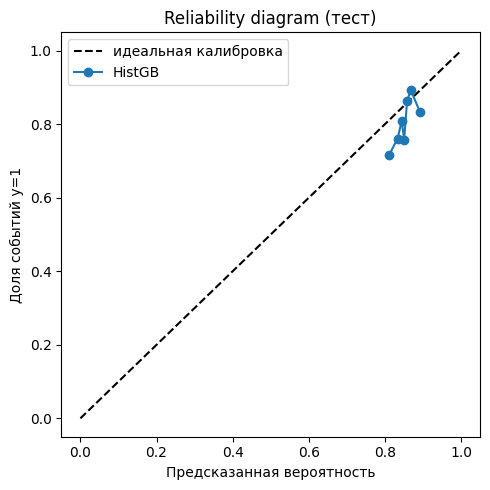

,secid,begin,close,p_hit_within_month
1091,GAZP,2026-05-21,118.67,0.865501
4363,SBER,2026-05-21,322.79,0.860675
3817,ROSN,2026-05-21,400.70,0.851418
3271,NVTK,2026-05-21,1119.40,0.846115
5451,VTBR,2026-05-21,89.70,0.841785
1633,GMKN,2026-05-21,128.80,0.836560
2179,LKOH,2026-05-21,5201.50,0.831926
4909,TATN,2026-05-21,634.00,0.828374
545,ALRS,2026-05-21,27.25,0.814328
2725,MGNT,2026-05-21,2420.50,0.810227


In [36]:
# --- Сравнение моделей и калибровка вероятностей ---
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score

def eval_classifier(name, model, X_tr, y_tr, X_te, y_te, calibrate: bool = False):
    if calibrate:
        model = CalibratedClassifierCV(
            model,
            cv=TimeSeriesSplit(n_splits=3),
            method="isotonic",
        )
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "auc": roc_auc_score(y_te, proba),
        "brier": brier_score_loss(y_te, proba),
        "bal_acc": balanced_accuracy_score(y_te, pred),
        "proba": proba,
        "estimator": model,
    }

results = []
results.append(eval_classifier(
    "LogReg+isotonic",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]),
    X_train, y_train, X_test, y_test,
    calibrate=True,
))
results.append(eval_classifier(
    "HistGB",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=4,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    X_train, y_train, X_test, y_test,
    calibrate=True,
))

cmp = pd.DataFrame([{k: v for k, v in r.items() if k not in ("proba", "estimator")} for r in results])
print("Сравнение на отложенных 20% дат:")
display(cmp.sort_values("auc", ascending=False))

best = max(results, key=lambda r: r["auc"])
print(f"Лучшая по AUC: {best['model']} (AUC={best['auc']:.3f}, Brier={best['brier']:.4f})")

# Диаграмма надёжности (калибровка) для лучшей модели
prob_true, prob_pred = calibration_curve(y_test, best["proba"], n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", label="идеальная калибровка")
ax.plot(prob_pred, prob_true, "o-", label=best["model"])
ax.set_xlabel("Предсказанная вероятность")
ax.set_ylabel("Доля событий y=1")
ax.set_title("Reliability diagram (тест)")
ax.legend()
plt.tight_layout()
plt.show()

# Прогнозы лучшей модели на последний день по каждому тикеру
best_clf = best["estimator"]
latest = ds.sort_values(["secid", "begin"]).groupby("secid").tail(1).copy()
latest["p_hit_within_month"] = best_clf.predict_proba(latest[feature_cols])[:, 1]
latest[["secid", "begin", "close", "p_hit_within_month"]].sort_values(
    "p_hit_within_month", ascending=False
)


## 6. Модель рискованности актива

**Постановка:** оцениваем вероятность **высокого риска** — события `y_high_risk = 1`.

**Событие:** за следующие `HORIZON_TRADING_DAYS` торговых дней минимальное **закрытие** оказывается ниже текущего `close` не менее чем на `RISK_DRAWDOWN_PCT` (просадка от точки наблюдения).

**Действия:**
- Тот же `ds` и те же признаки, другой таргет.
- Калиброванная логистическая регрессия (как в baseline).
- Метрики на тесте: ROC-AUC, Brier, balanced accuracy.
- Колонка **`p_high_risk`** — вероятность сильной просадки на последний день по тикеру.

**Смысл для НИР:** `p_hit_within_month` — «шанс роста», `p_high_risk` — «шанс болезненной просадки»; вместе дают двустороннюю картину.


In [37]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    balanced_accuracy_score,
    classification_report,
)

TARGET_RISK = "y_high_risk"

train_r, test_r, feature_cols_r = split_train_test(ds, train_frac=0.8)
# те же признаки, что и для модели роста (таргеты исключены в get_feature_cols)

X_train_r, y_train_r = train_r[feature_cols_r], train_r[TARGET_RISK]
X_test_r, y_test_r = test_r[feature_cols_r], test_r[TARGET_RISK]

risk_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

risk_clf = CalibratedClassifierCV(
    risk_pipe,
    cv=TimeSeriesSplit(n_splits=3),
    method="isotonic",
)
risk_clf.fit(X_train_r, y_train_r)

proba_risk = risk_clf.predict_proba(X_test_r)[:, 1]
pred_risk = (proba_risk >= 0.5).astype(int)

print(f"Доля {TARGET_RISK}=1 на тесте: {y_test_r.mean():.3f}")
print(f"Test ROC-AUC (риск):  {roc_auc_score(y_test_r, proba_risk):.3f}")
print(f"Test Brier (риск):    {brier_score_loss(y_test_r, proba_risk):.4f}")
print(f"Balanced accuracy:    {balanced_accuracy_score(y_test_r, pred_risk):.3f}")
print(classification_report(y_test_r, pred_risk, digits=3))

latest_risk = ds.sort_values(["secid", "begin"]).groupby("secid").tail(1).copy()
latest_risk["p_high_risk"] = risk_clf.predict_proba(latest_risk[feature_cols_r])[:, 1]
latest_risk[["secid", "begin", "close", "p_high_risk"]].sort_values("p_high_risk", ascending=False)


Доля y_high_risk=1 на тесте: 0.157
Test ROC-AUC (риск):  0.556
Test Brier (риск):    0.1613
Balanced accuracy:    0.547
              precision    recall  f1-score   support

           0      0.857     0.915     0.885       927
           1      0.282     0.179     0.219       173

    accuracy                          0.799      1100
   macro avg      0.569     0.547     0.552      1100
weighted avg      0.766     0.799     0.780      1100



,secid,begin,close,p_high_risk
2725,MGNT,2026-05-21,2420.50,0.565901
545,ALRS,2026-05-21,27.25,0.353343
5451,VTBR,2026-05-21,89.70,0.316710
2179,LKOH,2026-05-21,5201.50,0.314840
4363,SBER,2026-05-21,322.79,0.314840
4909,TATN,2026-05-21,634.00,0.314840
3817,ROSN,2026-05-21,400.70,0.272440
1091,GAZP,2026-05-21,118.67,0.188297
1633,GMKN,2026-05-21,128.80,0.170212
3271,NVTK,2026-05-21,1119.40,0.170212


## 7. Прогноз максимального роста за горизонт (%)

**Постановка:** регрессия на **`max_upside_pct`** — на сколько **процентов** максимальное **закрытие** в следующие 21 торговый день превысит сегодняшнее (если не превысит — 0%).

**Формула:** `max(0, (max(close_{t+1..t+21}) / close_t − 1) × 100)` по ценам в рублях.

**Почему чистая Ridge даёт слабый R²:** таргет сильно скошен (много нулей, редкие всплески), сигнал в признаках слабее, чем у классификаторов «рост / риск».

**Подход:**
- Признак **`ticker_exp_median_up`** — расширяющаяся медиана прошлых `max_upside_pct` по тикеру (без утечки).
- Ridge на **`log1p(max_upside_pct)`** (устойчивее к выбросам).
- **Смесь** с baseline: `α·ticker_exp_median_up + (1−α)·модель`, вес `α` подбирается по `TimeSeriesSplit` на train.
- Метрики: MAE, RMSE, R², корреляция Спирмена; сравнение с глобальной медианой и только baseline.
- **`pred_max_upside_pct`** — прогноз для последнего дня по тикеру.


In [38]:
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

TARGET_UPSIDE = "max_upside_pct"
BASELINE_UP = "ticker_exp_median_up"


def _upside_model_pipe():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=5.0)),
    ])


def _predict_upside_pct(pipe, X) -> np.ndarray:
    return np.clip(np.expm1(pipe.predict(X)), 0, None)


def _blend_upside(baseline: np.ndarray, model: np.ndarray, alpha: float) -> np.ndarray:
    return np.clip(alpha * baseline + (1.0 - alpha) * model, 0, None)


def _tune_blend_alpha(train_df, feature_cols, alpha_grid=None, mae_tol_pp: float = 0.08) -> float:
    """α для смеси: среди α с MAE ≈ лучшему на CV — максимизируем Spearman (ранжирование)."""
    if alpha_grid is None:
        alpha_grid = np.linspace(0, 1, 11)
    train_sorted = train_df.sort_values("begin").reset_index(drop=True)
    tscv = TimeSeriesSplit(n_splits=3)
    candidates: list[tuple[float, float, float]] = []
    for alpha in alpha_grid:
        fold_maes, fold_spears = [], []
        for tr_idx, va_idx in tscv.split(train_sorted):
            tr = train_sorted.iloc[tr_idx]
            va = train_sorted.iloc[va_idx]
            pipe = _upside_model_pipe()
            pipe.fit(tr[feature_cols], np.log1p(tr[TARGET_UPSIDE]))
            model_va = _predict_upside_pct(pipe, va[feature_cols])
            base_va = va[BASELINE_UP].to_numpy()
            pred_va = _blend_upside(base_va, model_va, alpha)
            fold_maes.append(mean_absolute_error(va[TARGET_UPSIDE], pred_va))
            fold_spears.append(spearmanr(va[TARGET_UPSIDE], pred_va).correlation)
        candidates.append((float(alpha), float(np.mean(fold_maes)), float(np.mean(fold_spears))))
    best_mae = min(c[1] for c in candidates)
    near = [c for c in candidates if c[1] <= best_mae + mae_tol_pp]
    return max(near, key=lambda c: c[2])[0]


def _report_upside(name: str, y_true, y_pred) -> None:
    print(
        f"{name:28s}  MAE={mean_absolute_error(y_true, y_pred):.2f}  "
        f"RMSE={mean_squared_error(y_true, y_pred) ** 0.5:.2f}  "
        f"R²={r2_score(y_true, y_pred):.3f}  "
        f"Spearman={spearmanr(y_true, y_pred).correlation:.3f}"
    )


train_u, test_u, fc_u = split_train_test(ds, train_frac=0.8)
X_tr_u, y_tr_u = train_u[fc_u], train_u[TARGET_UPSIDE]
X_te_u, y_te_u = test_u[fc_u], test_u[TARGET_UPSIDE]

blend_alpha = _tune_blend_alpha(train_u, fc_u)
upside_reg = _upside_model_pipe()
upside_reg.fit(X_tr_u, np.log1p(y_tr_u))

base_te = test_u[BASELINE_UP].to_numpy()
model_te = _predict_upside_pct(upside_reg, X_te_u)
pred_up = _blend_upside(base_te, model_te, blend_alpha)

print(f"Вес baseline на CV (α): {blend_alpha:.2f}")
print(f"Факт на тесте: mean={y_te_u.mean():.2f}%, median={y_te_u.median():.2f}%")
print("— сравнение на тесте —")
_report_upside("Глобальная медиана train", y_te_u, np.full(len(y_te_u), y_tr_u.median()))
_report_upside("Только ticker_exp_median_up", y_te_u, base_te)
_report_upside("Только Ridge (log-таргет)", y_te_u, model_te)
_report_upside("Гибрид (итог)", y_te_u, pred_up)

latest_up = ds.sort_values(["secid", "begin"]).groupby("secid").tail(1).copy()
latest_base = latest_up[BASELINE_UP].to_numpy()
latest_model = _predict_upside_pct(upside_reg, latest_up[fc_u])
latest_up["pred_max_upside_pct"] = _blend_upside(latest_base, latest_model, blend_alpha)

display(
    latest_up[
        ["secid", "begin", "close", BASELINE_UP, "max_upside_pct", "pred_max_upside_pct"]
    ].sort_values("pred_max_upside_pct", ascending=False)
)


Вес baseline на CV (α): 0.80
Факт на тесте: mean=3.75%, median=2.03%
— сравнение на тесте —
Глобальная медиана train      MAE=3.42  RMSE=5.07  R²=-0.006  Spearman=nan
Только ticker_exp_median_up   MAE=3.42  RMSE=5.05  R²=0.003  Spearman=0.109
Только Ridge (log-таргет)     MAE=3.29  RMSE=5.43  R²=-0.152  Spearman=-0.019
Гибрид (итог)                 MAE=3.36  RMSE=5.09  R²=-0.013  Spearman=0.066


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


,secid,begin,close,ticker_exp_median_up,max_upside_pct,pred_max_upside_pct
1633,GMKN,2026-05-21,128.80,4.410585,0.822981,4.194733
4909,TATN,2026-05-21,634.00,4.121159,0.000000,3.836590
3271,NVTK,2026-05-21,1119.40,3.593873,0.223334,3.412442
2725,MGNT,2026-05-21,2420.50,3.501335,1.136129,3.152986
2179,LKOH,2026-05-21,5201.50,3.374605,0.865135,3.129971
1091,GAZP,2026-05-21,118.67,2.985669,0.463470,2.931925
5451,VTBR,2026-05-21,89.70,3.209877,0.780379,2.910943
4363,SBER,2026-05-21,322.79,2.978083,0.777595,2.668138
3817,ROSN,2026-05-21,400.70,2.743695,0.798602,2.645884
545,ALRS,2026-05-21,27.25,2.755839,0.366972,2.585949


## 8. Сводка и топ-5 портфеля (по 100 000 ₽ на бумагу)

**Действия:**
- Сводная таблица по всем тикерам: `p_hit_within_month`, `p_high_risk`, `pred_max_upside_pct`, `risk_return_score`.
- **Топ-5** по `invest_score = p_hit_within_month − p_high_risk + pred_max_upside_pct/100`.
- В каждую из топ-5 бумаг — **100 000 ₽**; считаются `shares`, `invested_rub`, остаток и условный апсайд в ₽.

**Осторожно:** учебный пример, не инвестиционная рекомендация.


In [39]:
from IPython.display import display

latest_growth = ds.sort_values(["secid", "begin"]).groupby("secid").tail(1).copy()
latest_growth["p_hit_within_month"] = cal_clf.predict_proba(latest_growth[feature_cols])[:, 1]

summary = (
    latest_growth[["secid", "begin", "close", "p_hit_within_month"]]
    .merge(latest_risk[["secid", "p_high_risk"]], on="secid", how="inner")
    .merge(latest_up[["secid", "pred_max_upside_pct"]], on="secid", how="inner")
)
summary["risk_return_score"] = summary["p_hit_within_month"] - summary["p_high_risk"]

print("Сводная таблица (последний торговый день по каждому тикеру):")
display(summary.sort_values("risk_return_score", ascending=False)[
    ["secid", "begin", "close", "p_hit_within_month", "p_high_risk", "pred_max_upside_pct", "risk_return_score"]
])

# --- Топ-5 для условного портфеля: по 100 000 ₽ на бумагу ---
INVEST_PER_ASSET_RUB = 100_000
TOP_N = 5

port = summary.copy()
port["invest_score"] = (
    port["p_hit_within_month"] - port["p_high_risk"] + port["pred_max_upside_pct"] / 100.0
)
top5 = port.sort_values("invest_score", ascending=False).head(TOP_N).copy()
top5["rank"] = range(1, len(top5) + 1)
top5["invest_rub"] = INVEST_PER_ASSET_RUB
top5["shares"] = (top5["invest_rub"] / top5["close"]).astype(int)
top5["invested_rub"] = top5["shares"] * top5["close"]
top5["cash_remainder_rub"] = top5["invest_rub"] - top5["invested_rub"]
top5["exp_upside_rub_model"] = top5["invested_rub"] * top5["pred_max_upside_pct"] / 100.0

print(f"\nТоп-{TOP_N} (по invest_score), в каждый — {INVEST_PER_ASSET_RUB:,} ₽:")
print(f"Бюджет: {top5['invest_rub'].sum():,} ₽ | В акции: {top5['invested_rub'].sum():,.0f} ₽")
display(top5[[
    "rank", "secid", "close", "invest_score",
    "p_hit_within_month", "p_high_risk", "pred_max_upside_pct",
    "invest_rub", "shares", "invested_rub", "cash_remainder_rub", "exp_upside_rub_model",
]])


Сводная таблица (последний торговый день по каждому тикеру):


,secid,begin,close,p_hit_within_month,p_high_risk,pred_max_upside_pct,risk_return_score
2,GMKN,2026-05-21,128.80,0.896047,0.170212,4.194733,0.725835
5,NVTK,2026-05-21,1119.40,0.883623,0.170212,3.412442,0.713411
1,GAZP,2026-05-21,118.67,0.883623,0.188297,2.931925,0.695326
6,ROSN,2026-05-21,400.70,0.851218,0.272440,2.645884,0.578779
3,LKOH,2026-05-21,5201.50,0.843290,0.314840,3.129971,0.528449
8,TATN,2026-05-21,634.00,0.843290,0.314840,3.836590,0.528449
9,VTBR,2026-05-21,89.70,0.845085,0.316710,2.910943,0.528374
7,SBER,2026-05-21,322.79,0.840912,0.314840,2.668138,0.526072
0,ALRS,2026-05-21,27.25,0.629867,0.353343,2.585949,0.276524
4,MGNT,2026-05-21,2420.50,0.546534,0.565901,3.152986,-0.019367



Топ-5 (по invest_score), в каждый — 100,000 ₽:
Бюджет: 500,000 ₽ | В акции: 498,808 ₽


,rank,secid,close,invest_score,p_hit_within_month,p_high_risk,pred_max_upside_pct,invest_rub,shares,invested_rub,cash_remainder_rub,exp_upside_rub_model
2,1,GMKN,128.80,0.767782,0.896047,0.170212,4.194733,100000,776,99948.80,51.20,4192.584963
5,2,NVTK,1119.40,0.747536,0.883623,0.170212,3.412442,100000,89,99626.60,373.40,3399.700360
1,3,GAZP,118.67,0.724646,0.883623,0.188297,2.931925,100000,842,99920.14,79.86,2929.583365
6,4,ROSN,400.70,0.605238,0.851218,0.272440,2.645884,100000,249,99774.30,225.70,2639.912303
8,5,TATN,634.00,0.566815,0.843290,0.314840,3.836590,100000,157,99538.00,462.00,3818.864504
